In [1]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import numpy.ma as ma

In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
path='/content/drive/My Drive/Work7_MAUNet_Light_Data_Model_Result'

In [4]:
MAUNet_Test_Grid=np.load(path+'/Result/DailyGridded/Work7_MAUNet_TRMMIMD_TestResult.npy')
SRDRN_Test_Grid=np.load(path+'/Result/DailyGridded/Work7_SRDRN_TRMMIMD_TestResult.npy')
MAUNet_Light_KR_Test_Grid=np.load(path+'/Result/DailyGridded/Work7_MAUNet_Light_KR_TRMMIMD_TestResult.npy')
MAUNet_Light_GT_Test_Grid=np.load(path+'/Result/DailyGridded/Work7_MAUNet_Light_TrainWithGT_TRMMIMD_TestResult.npy')
MAUNet_Light_MP_Test_Grid=np.load(path+'/Result/DailyGridded/Work7_MAUNet_Light_TrainWithTeacherPred_TRMMIMD_TestResult.npy')
QDM_Test_Grid=np.load(path+'/Result/DailyGridded/Work7_QDM_TRMMIMD_TestResult.npy')
QM_Test_Grid=np.load(path+'/Result/DailyGridded/Work7_QM_TRMMIMD_TestResult.npy')
BiasData_Test_Grid=np.load(path+'/Result/DailyGridded/Work7_BiasData_Test_TRMMIMD.npy')
Label_Test_Grid=np.load(path+'/Result/DailyGridded/Work7_Label_Test_TRMMIMD.npy')

In [5]:
datamask=np.load(path+"/Data/Mask-TRMM128x128.npy")

In [8]:
def Th_class(data,th):
  data_class=np.where(data<th, 0, 1)
  return data_class

In [9]:
#Calculating F1_Score and Accuracy
def confusion(Actual,Predicted,datamask,cls):
  TP=0
  TN=0
  FP=0
  FN=0
  for i in range(0,np.shape(Actual)[0]):
    for j in range(0,np.shape(Actual)[1]):
      for k in range(0,np.shape(Actual)[2]):
        if datamask[j][k]==0:
          if Actual[i][j][k]==Predicted[i][j][k]==cls:
            TP=TP+1
          elif Actual[i][j][k]==cls and Predicted[i][j][k]!=cls:
            FN=FN+1
          elif Actual[i][j][k]!=cls and Predicted[i][j][k]!=cls:
            TN=TN+1
          elif Actual[i][j][k]!=cls and Predicted[i][j][k]==cls:
            FP=FP+1
  Precision=TP/(TP+FP)
  Recall=TP/(TP+FN)
  F1_Score=(2*Precision*Recall)/(Precision+Recall)
  Accuracy=(TP+TN)/(TP+FP+TN+FN)
  return F1_Score, Accuracy

In [10]:
Label_class20 =Th_class(Label_Test_Grid,20)
MAUNet_class20 =Th_class(MAUNet_Test_Grid,20)
SRDRN_class20 =Th_class(SRDRN_Test_Grid,20)
MAUNet_Light_KR_class20 =Th_class(MAUNet_Light_KR_Test_Grid,20)
MAUNet_Light_GT_class20 =Th_class(MAUNet_Light_GT_Test_Grid,20)
MAUNet_Light_MP_class20 =Th_class(MAUNet_Light_MP_Test_Grid,20)
QDM_class20 =Th_class(QDM_Test_Grid,20)
QM_class20 =Th_class(QM_Test_Grid,20)
BiasData_class20 =Th_class(BiasData_Test_Grid,20)

In [11]:

print("***********************************************************************")

MAUNet_Fscore20, MAUNet_Accuracy20 = confusion(Label_class20, MAUNet_class20, datamask, 1)
print("MAUNet F_Score for Th20 : ", np.round(MAUNet_Fscore20, 4))
print("MAUNet Accuracy for Th20 : ", np.round(MAUNet_Accuracy20, 4))

print("************************************************************************")

SRDRN_Fscore20, SRDRN_Accuracy20 = confusion(Label_class20, SRDRN_class20, datamask, 1)
print("SRDRN F_Score for Th20 : ", np.round(SRDRN_Fscore20, 4))
print("SRDRN Accuracy for Th20 : ", np.round(SRDRN_Accuracy20, 4))

print("************************************************************************")

MAUNet_Light_KR_Fscore20, MAUNet_Light_KR_Accuracy20 = confusion(Label_class20, MAUNet_Light_KR_class20, datamask, 1)
print("MAUNet_Light_KR F_Score for Th20 : ", np.round(MAUNet_Light_KR_Fscore20, 4))
print("MAUNet_Light_KR Accuracy for Th20 : ", np.round(MAUNet_Light_KR_Accuracy20, 4))

print("************************************************************************")

MAUNet_Light_GT_Fscore20, MAUNet_Light_GT_Accuracy20 = confusion(Label_class20, MAUNet_Light_GT_class20, datamask, 1)
print("MAUNet_Light_GT F_Score for Th20 : ", np.round(MAUNet_Light_GT_Fscore20, 4))
print("MAUNet_Light_GT Accuracy for Th20 : ", np.round(MAUNet_Light_GT_Accuracy20, 4))

print("************************************************************************")

MAUNet_Light_MP_Fscore20, MAUNet_Light_MP_Accuracy20 = confusion(Label_class20, MAUNet_Light_MP_class20, datamask, 1)
print("MAUNet_Light_MP F_Score for Th20 : ", np.round(MAUNet_Light_MP_Fscore20, 4))
print("MAUNet_Light_MP Accuracy for Th20 : ", np.round(MAUNet_Light_MP_Accuracy20, 4))

print("************************************************************************")

QDM_Fscore20, QDM_Accuracy20 = confusion(Label_class20, QDM_class20, datamask, 1)
print("QDM F_Score for Th20 : ", np.round(QDM_Fscore20, 4))
print("QDM Accuracy for Th20 : ", np.round(QDM_Accuracy20, 4))

print("************************************************************************")

QM_Fscore20, QM_Accuracy20 = confusion(Label_class20, QM_class20, datamask, 1)
print("QM F_Score for Th20 : ", np.round(QM_Fscore20, 4))
print("QM Accuracy for Th20 : ", np.round(QM_Accuracy20, 4))

print("************************************************************************")

BiasData_Fscore20, BiasData_Accuracy20 = confusion(Label_class20, BiasData_class20, datamask, 1)
print("BiasData F_Score for Th20 : ", np.round(BiasData_Fscore20, 4))
print("BiasData Accuracy for Th20 : ", np.round(BiasData_Accuracy20, 4))

print("************************************************************************")


***********************************************************************
MAUNet F_Score for Th20 :  0.524
MAUNet Accuracy for Th20 :  0.9142
************************************************************************
SRDRN F_Score for Th20 :  0.5051
SRDRN Accuracy for Th20 :  0.9112
************************************************************************
MAUNet_Light_KR F_Score for Th20 :  0.5246
MAUNet_Light_KR Accuracy for Th20 :  0.9131
************************************************************************
MAUNet_Light_GT F_Score for Th20 :  0.5242
MAUNet_Light_GT Accuracy for Th20 :  0.912
************************************************************************
MAUNet_Light_MP F_Score for Th20 :  0.5139
MAUNet_Light_MP Accuracy for Th20 :  0.9138
************************************************************************
QDM F_Score for Th20 :  0.4979
QDM Accuracy for Th20 :  0.8973
************************************************************************
QM F_Score for Th20 :  0.4995
QM

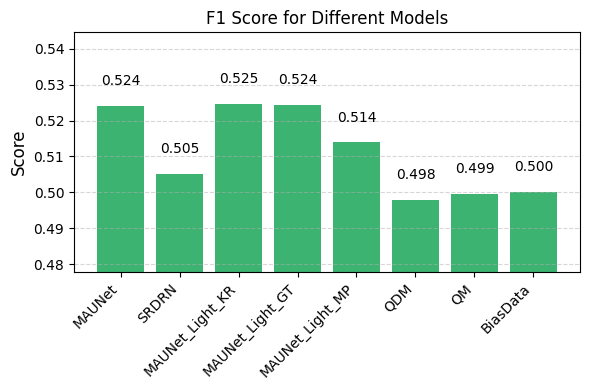

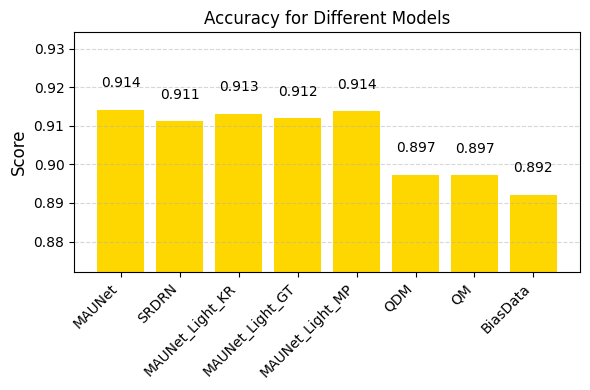

In [13]:
import matplotlib.pyplot as plt

models = [
    'MAUNet',
    'SRDRN',
    'MAUNet_Light_KR',
    'MAUNet_Light_GT',
    'MAUNet_Light_MP',
    'QDM',
    'QM',
    'BiasData'
]

f1_score = [
    MAUNet_Fscore20,
    SRDRN_Fscore20,
    MAUNet_Light_KR_Fscore20,
    MAUNet_Light_GT_Fscore20,
    MAUNet_Light_MP_Fscore20,
    QDM_Fscore20,
    QM_Fscore20,
    BiasData_Fscore20
]

accuracy = [
    MAUNet_Accuracy20,
    SRDRN_Accuracy20,
    MAUNet_Light_KR_Accuracy20,
    MAUNet_Light_GT_Accuracy20,
    MAUNet_Light_MP_Accuracy20,
    QDM_Accuracy20,
    QM_Accuracy20,
    BiasData_Accuracy20
]

# Convert to numpy arrays
f_scores = np.array(f1_score)
accuracies = np.array(accuracy)



# Custom plot function with dynamic y-limits
def plot_metric(metric, values, color):
    plt.figure(figsize=(6, 4))
    bars = plt.bar(models, values, color=color)

    # Dynamic y-axis range
    ymin = min(values) - 0.02
    ymax = max(values) + 0.02
    plt.ylim(ymin, ymax)

    # Annotate each bar with its value
    for bar in bars:
        yval = bar.get_height()
        plt.text(bar.get_x() + bar.get_width()/2.0, yval + 0.005, f"{yval:.3f}",
                 ha='center', va='bottom', fontsize=10)

    plt.xticks(rotation=45, ha='right')
    plt.ylabel("Score", fontsize=12)
    plt.title(f"{metric} for Different Models", fontsize=12)
    plt.grid(axis='y', linestyle='--', alpha=0.5)
    plt.tight_layout()
    plt.show()

# Generate separate plots
plot_metric("F1 Score", f1_score, "mediumseagreen")
plot_metric("Accuracy", accuracy, "gold")
